In [10]:
import numpy
import pandas as pd
import os
from src.data_loader import prepare_paths, load_horizontal_well, load_typewell
from src.features import (generate_signal_features, generate_spatial_features,
        integrate_with_typewells, full_preprocessing_pipeline)
import matplotlib.pyplot as plt

In [2]:
PATH_TRAIN = 'train'
PATH_TEST = 'test'

In [3]:
paths_train = prepare_paths(PATH_TRAIN)
paths_test = prepare_paths(PATH_TEST)
paths_train[:3]

[['train/000d7d20__horizontal_well.csv', 'train/000d7d20__typewell.csv'],
 ['train/00bbac68__horizontal_well.csv', 'train/00bbac68__typewell.csv'],
 ['train/00e12e8b__horizontal_well.csv', 'train/00e12e8b__typewell.csv']]

In [4]:
examples = full_preprocessing_pipeline(*paths_train[0])
examples.head()

/Users/iaroslav/Downloads/wellbore-geology-prediction/src/features.py:19: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[f'gr_lag_{lag}'] = df['GR'].shift(lag).fillna(method='bfill')
/Users/iaroslav/Downloads/wellbore-geology-prediction/src/features.py:20: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[f'gr_lead_{lag}'] = df['GR'].shift(-lag).fillna(method='ffill')
/Users/iaroslav/Downloads/wellbore-geology-prediction/src/features.py:19: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[f'gr_lag_{lag}'] = df['GR'].shift(lag).fillna(method='bfill')
/Users/iaroslav/Downloads/wellbore-geology-prediction/src/features.py:20: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.f

,MD,X,Y,Z,TVT,GR,TVT_input,gr_roll_mean_5,gr_roll_std_5,gr_roll_min_5,...,gr_lead_2,gr_lag_3,gr_lead_3,delta_X,delta_Y,delta_Z,trajectory_slope,tw_reference_GR,tw_reference_TVT,gr_difference_to_tw
0,11467.0,2983525.16,1069022.09,-9258.57,11236.02,115.692586,11236.02,122.241280,11.436583,115.584293,...,135.446960,115.692586,140.401346,0.00,0.00,0.00,0.000000,115.53,11340.45,0.162586
1,11468.0,2983525.18,1069022.30,-9259.55,11237.05,115.584293,11237.05,126.781296,13.024744,115.584293,...,140.401346,115.692586,111.270638,0.02,0.21,-0.98,-4.645624,115.53,11340.45,0.054293
2,11469.0,2983525.20,1069022.52,-9260.52,11238.09,135.446960,11238.09,123.679165,13.241943,111.270638,...,111.270638,115.692586,108.779909,0.02,0.22,-0.97,-4.390964,135.14,11275.45,0.306960
3,11470.0,2983525.22,1069022.73,-9261.50,11239.12,140.401346,11239.12,122.296629,14.577737,108.779909,...,108.779909,115.692586,114.338929,0.02,0.21,-0.98,-4.645624,139.44,11252.95,0.961346
4,11471.0,2983525.25,1069022.95,-9262.47,11240.15,111.270638,11240.15,122.047556,14.730928,108.779909,...,114.338929,115.584293,121.459167,0.03,0.22,-0.97,-4.368641,111.25,11318.45,0.020638


In [9]:
sum_ = 0
for p_test in paths_test:
    test_values = full_preprocessing_pipeline(*p_test)

    mean_na = test_values['TVT_input'].isna().mean()
    sum_ += mean_na
    print(mean_na)

print(sum_/3)
test_values.head(4)

0.726790450928382
0.7956078846408255
0.6737155388471178
0.732037958138775


/Users/iaroslav/Downloads/wellbore-geology-prediction/src/features.py:19: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[f'gr_lag_{lag}'] = df['GR'].shift(lag).fillna(method='bfill')
/Users/iaroslav/Downloads/wellbore-geology-prediction/src/features.py:20: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[f'gr_lead_{lag}'] = df['GR'].shift(-lag).fillna(method='ffill')
/Users/iaroslav/Downloads/wellbore-geology-prediction/src/features.py:19: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[f'gr_lag_{lag}'] = df['GR'].shift(lag).fillna(method='bfill')
/Users/iaroslav/Downloads/wellbore-geology-prediction/src/features.py:20: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.f

,MD,X,Y,Z,GR,TVT_input,gr_roll_mean_5,gr_roll_std_5,gr_roll_min_5,gr_roll_max_5,...,gr_lead_2,gr_lag_3,gr_lead_3,delta_X,delta_Y,delta_Z,trajectory_slope,tw_reference_GR,tw_reference_TVT,gr_difference_to_tw
0,10456.0,2971071.98,1060431.23,-8356.04,109.368306,10606.18,112.697046,5.765546,109.368306,119.354526,...,119.354526,109.368306,121.370974,0.00,0.00,0.00,0.000000,109.36,10961.95,0.008306
1,10457.0,2971071.97,1060431.29,-8357.03,109.368306,10607.53,114.865528,6.400803,109.368306,121.370974,...,121.370974,109.368306,123.387422,-0.01,0.06,-0.99,-16.275232,109.36,10961.95,0.008306
2,10458.0,2971071.95,1060431.35,-8358.03,119.354526,10608.88,116.569907,6.726979,109.368306,123.387422,...,123.387422,109.368306,118.010227,-0.02,0.06,-1.00,-15.811138,119.37,11694.95,0.015474
3,10459.0,2971071.93,1060431.41,-8359.03,121.370974,10610.22,118.298291,5.391750,109.368306,123.387422,...,118.010227,109.368306,117.434099,-0.02,0.06,-1.00,-15.811138,121.39,11166.45,0.019026


In [7]:
columns_train = examples.columns.tolist()
columns_test = test_values.columns.tolist()
print(columns_train)
print(columns_test)
len(columns_train), len(columns_test) #ok

['MD', 'X', 'Y', 'Z', 'TVT', 'GR', 'TVT_input', 'gr_roll_mean_5', 'gr_roll_std_5', 'gr_roll_min_5', 'gr_roll_max_5', 'gr_diff_5', 'gr_roll_mean_11', 'gr_roll_std_11', 'gr_roll_min_11', 'gr_roll_max_11', 'gr_diff_11', 'gr_roll_mean_21', 'gr_roll_std_21', 'gr_roll_min_21', 'gr_roll_max_21', 'gr_diff_21', 'gr_lag_1', 'gr_lead_1', 'gr_lag_2', 'gr_lead_2', 'gr_lag_3', 'gr_lead_3', 'delta_X', 'delta_Y', 'delta_Z', 'trajectory_slope', 'tw_reference_GR', 'tw_reference_TVT', 'gr_difference_to_tw']
['MD', 'X', 'Y', 'Z', 'GR', 'TVT_input', 'gr_roll_mean_5', 'gr_roll_std_5', 'gr_roll_min_5', 'gr_roll_max_5', 'gr_diff_5', 'gr_roll_mean_11', 'gr_roll_std_11', 'gr_roll_min_11', 'gr_roll_max_11', 'gr_diff_11', 'gr_roll_mean_21', 'gr_roll_std_21', 'gr_roll_min_21', 'gr_roll_max_21', 'gr_diff_21', 'gr_lag_1', 'gr_lead_1', 'gr_lag_2', 'gr_lead_2', 'gr_lag_3', 'gr_lead_3', 'delta_X', 'delta_Y', 'delta_Z', 'trajectory_slope', 'tw_reference_GR', 'tw_reference_TVT', 'gr_difference_to_tw']


(35, 34)

/Users/iaroslav/Downloads/wellbore-geology-prediction/src/features.py:19: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[f'gr_lag_{lag}'] = df['GR'].shift(lag).fillna(method='bfill')
/Users/iaroslav/Downloads/wellbore-geology-prediction/src/features.py:20: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[f'gr_lead_{lag}'] = df['GR'].shift(-lag).fillna(method='ffill')
/Users/iaroslav/Downloads/wellbore-geology-prediction/src/features.py:19: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[f'gr_lag_{lag}'] = df['GR'].shift(lag).fillna(method='bfill')
/Users/iaroslav/Downloads/wellbore-geology-prediction/src/features.py:20: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.f

Text(0.5, 0.98, 'md/tvt corr')

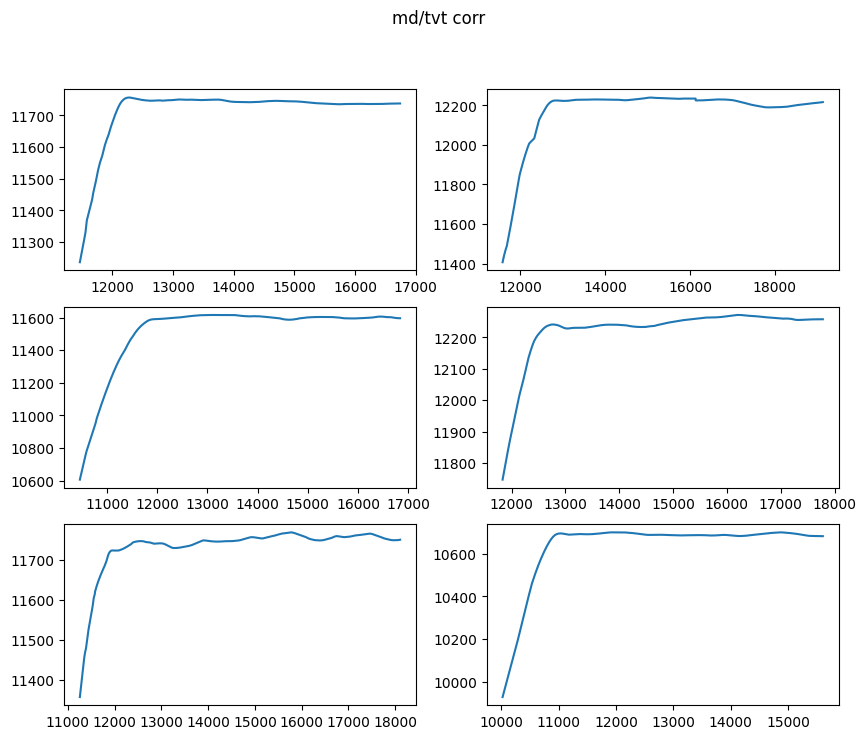

In [12]:
train_for_hist = []
for p_train in paths_train[:6]:
    new_train = full_preprocessing_pipeline(*p_train)
    train_for_hist.append(new_train)

fig, axes = plt.subplots(3, 2, figsize=(10, 8))
for i in range(6):
    X = train_for_hist[i]['MD']
    y = train_for_hist[i]['TVT']

    row = i // 2
    col = i % 2
    axes[row, col].plot(X, y)

plt.suptitle('md/tvt corr')